# Google Search Trends Analysis in India - 2026

## Introduction

This project analyzes Google search interest for ChatGPT in India during 2026 using Google Trends data.

The objective is to understand search patterns, identify peak search periods, examine changes in search interest over time, and derive meaningful insights from the data.

## 1. Importing Libraries

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

print("All libraries imported successfully!")

All libraries imported successfully!


In [139]:
from pytrends.request import TrendReq

pytrends = TrendReq(
    hl="en-IN",
    tz=330
)

print("Google Trends connection created successfully!")

Google Trends connection created successfully!


In [140]:
keywords = [
    "ChatGPT",
    "Google Gemini",
    "Machine Learning",
    "Python",
    "Data Science"
]

pytrends.build_payload(
    keywords,
    timeframe="2026-01-01 2026-09-24",
    geo="IN",
    gprop=""
)

data = pytrends.interest_over_time()

data.head()

/opt/anaconda3/lib/python3.13/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,ChatGPT,Google Gemini,Machine Learning,Python,Data Science,isPartial
date,,,,,,
2026-01-01,43,8,1,4,1,False
2026-01-02,54,7,1,4,1,False
2026-01-03,48,7,1,4,1,False
2026-01-04,41,7,1,4,1,False
2026-01-05,58,7,1,5,1,False


In [141]:
print(data.shape)

(267, 6)


In [142]:
print(data.columns)

Index(['ChatGPT', 'Google Gemini', 'Machine Learning', 'Python',
       'Data Science', 'isPartial'],
      dtype='object')


In [143]:
data.head(10)

,ChatGPT,Google Gemini,Machine Learning,Python,Data Science,isPartial
date,,,,,,
2026-01-01,43,8,1,4,1,False
2026-01-02,54,7,1,4,1,False
2026-01-03,48,7,1,4,1,False
2026-01-04,41,7,1,4,1,False
2026-01-05,58,7,1,5,1,False
2026-01-06,56,7,1,6,1,False
2026-01-07,59,7,1,6,1,False
2026-01-08,57,7,1,6,1,False
2026-01-09,55,7,1,5,1,False


In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 267 entries, 2026-01-01 to 2026-09-24
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ChatGPT           267 non-null    int64
 1   Google Gemini     267 non-null    int64
 2   Machine Learning  267 non-null    int64
 3   Python            267 non-null    int64
 4   Data Science      267 non-null    int64
 5   isPartial         267 non-null    bool 
dtypes: bool(1), int64(5)
memory usage: 12.8 KB


In [145]:
data.isnull().sum()

ChatGPT             0
Google Gemini       0
Machine Learning    0
Python              0
Data Science        0
isPartial           0
dtype: int64

## 2. Loading the Dataset

In [146]:
import pandas as pd

file_path = "../data/raw/chatgpt_india_2026.csv"

df = pd.read_csv(file_path)

df.head()

,Time,chatgpt
0,2026-01-04,71
1,2026-01-11,66
2,2026-01-18,74
3,2026-01-25,69
4,2026-02-01,71


## 3. Understanding the Dataset

In [147]:
df.shape

(38, 2)

In [148]:
df.columns

Index(['Time', 'chatgpt'], dtype='object')

In [149]:
df.head(10)

,Time,chatgpt
0,2026-01-04,71
1,2026-01-11,66
2,2026-01-18,74
3,2026-01-25,69
4,2026-02-01,71
5,2026-02-08,67
6,2026-02-15,73
7,2026-02-22,77
8,2026-03-01,73
9,2026-03-08,78


In [150]:
df.tail(10)

,Time,chatgpt
28,2026-07-19,81
29,2026-07-26,81
30,2026-08-02,79
31,2026-08-09,83
32,2026-08-16,87
33,2026-08-23,79
34,2026-08-30,89
35,2026-09-06,100
36,2026-09-13,65
37,2026-09-20,66


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Time     38 non-null     object
 1   chatgpt  38 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


In [152]:
df.isnull().sum()

Time       0
chatgpt    0
dtype: int64

In [153]:
df.describe()

,chatgpt
count,38.000000
mean,75.684211
std,6.854098
min,65.000000
25%,72.000000
50%,75.000000
75%,78.750000
max,100.000000


## 4. Data Cleaning

In [154]:
df["Time"] = pd.to_datetime(df["Time"])

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Time     38 non-null     datetime64[ns]
 1   chatgpt  38 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 740.0 bytes


In [156]:
print("Start date:", df["Time"].min())
print("End date:", df["Time"].max())

Start date: 2026-01-04 00:00:00
End date: 2026-09-20 00:00:00


## 5. Exploratory Data Analysis

In [157]:
max_interest = df["chatgpt"].max()

print("Highest search interest:", max_interest)

Highest search interest: 100


In [158]:
peak_row = df.loc[df["chatgpt"].idxmax()]

print(peak_row)

Time       2026-09-06 00:00:00
chatgpt                    100
Name: 35, dtype: object


In [159]:
min_interest = df["chatgpt"].min()

print("Lowest search interest:", min_interest)

Lowest search interest: 65


In [160]:
lowest_row = df.loc[df["chatgpt"].idxmin()]

print(lowest_row)

Time       2026-09-13 00:00:00
chatgpt                     65
Name: 36, dtype: object


## 6. Data Visualization

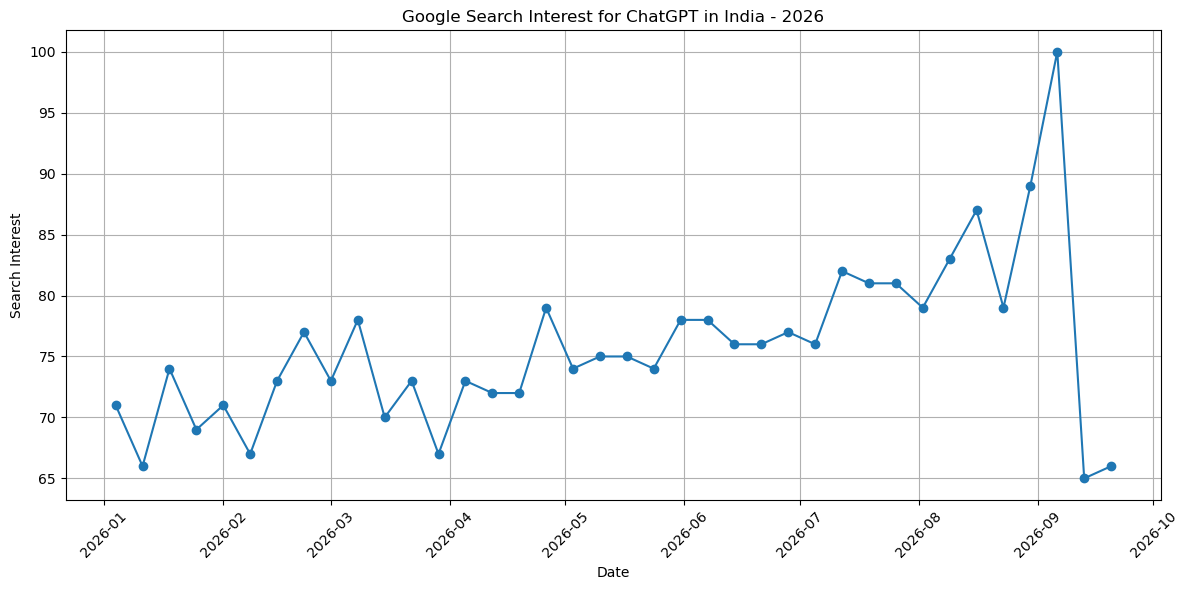

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df["Time"],
    df["chatgpt"],
    marker="o"
)

plt.title("Google Search Interest for ChatGPT in India - 2026")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

## 7. Detailed Exploratory Data Analysis

In this section, we analyze the distribution of Google search interest, identify high and low interest periods, and examine how search interest changes over time.

In [162]:
mean_interest = df["chatgpt"].mean()

print("Average search interest:", round(mean_interest, 2))

Average search interest: 75.68


In [163]:
peak_index = df["chatgpt"].idxmax()

peak_date = df.loc[peak_index, "Time"]
peak_interest = df.loc[peak_index, "chatgpt"]

print("Peak date:", peak_date)
print("Peak search interest:", peak_interest)

Peak date: 2026-09-06 00:00:00
Peak search interest: 100


In [164]:
lowest_index = df["chatgpt"].idxmin()

lowest_date = df.loc[lowest_index, "Time"]
lowest_interest = df.loc[lowest_index, "chatgpt"]

print("Lowest-interest date:", lowest_date)
print("Lowest search interest:", lowest_interest)

Lowest-interest date: 2026-09-13 00:00:00
Lowest search interest: 65


In [165]:
top_10 = df.nlargest(10, "chatgpt")

top_10

,Time,chatgpt
35,2026-09-06,100
34,2026-08-30,89
32,2026-08-16,87
31,2026-08-09,83
27,2026-07-12,82
28,2026-07-19,81
29,2026-07-26,81
16,2026-04-26,79
30,2026-08-02,79
33,2026-08-23,79


In [166]:
top_10[["Time", "chatgpt"]]

,Time,chatgpt
35,2026-09-06,100
34,2026-08-30,89
32,2026-08-16,87
31,2026-08-09,83
27,2026-07-12,82
28,2026-07-19,81
29,2026-07-26,81
16,2026-04-26,79
30,2026-08-02,79
33,2026-08-23,79


In [167]:
bottom_10 = df.nsmallest(10, "chatgpt")

bottom_10[["Time", "chatgpt"]]

,Time,chatgpt
36,2026-09-13,65
1,2026-01-11,66
37,2026-09-20,66
5,2026-02-08,67
12,2026-03-29,67
3,2026-01-25,69
10,2026-03-15,70
0,2026-01-04,71
4,2026-02-01,71
14,2026-04-12,72


### 7.1 Moving Average

A moving average helps smooth short-term fluctuations and makes the overall search-interest trend easier to observe.

In [168]:
df["Moving_Average"] = df["chatgpt"].rolling(window=4).mean()

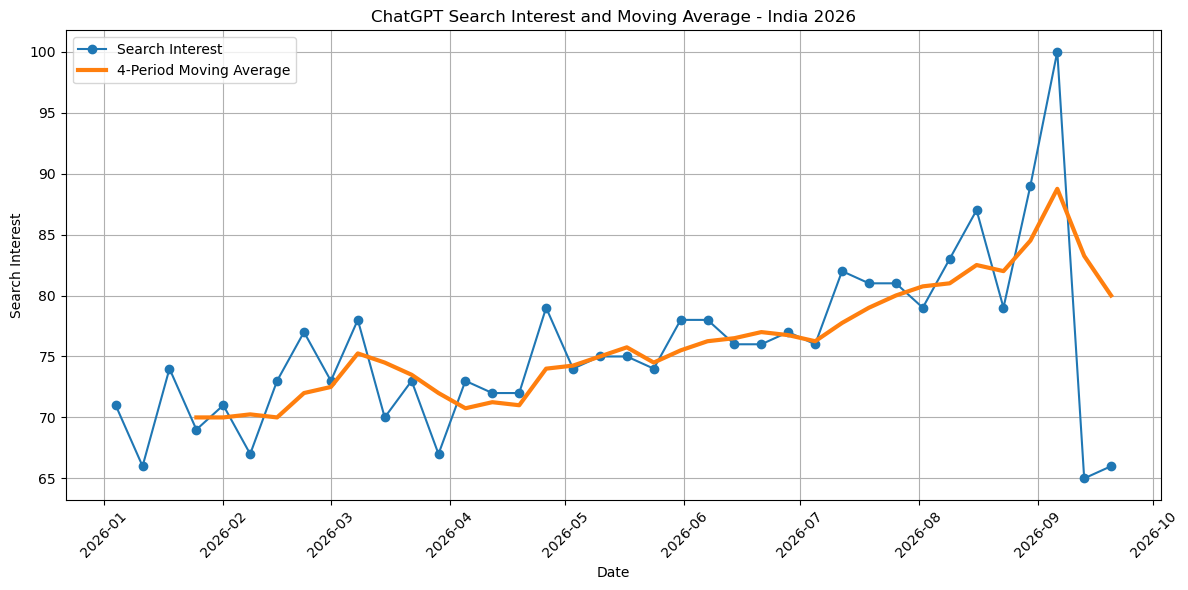

In [169]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Time"],
    df["chatgpt"],
    marker="o",
    label="Search Interest"
)

plt.plot(
    df["Time"],
    df["Moving_Average"],
    linewidth=3,
    label="4-Period Moving Average"
)

plt.title("ChatGPT Search Interest and Moving Average - India 2026")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

In [170]:
df["Change"] = df["chatgpt"].diff()

In [171]:
df[["Time", "chatgpt", "Change"]].head(10)

,Time,chatgpt,Change
0,2026-01-04,71,NaN
1,2026-01-11,66,-5.0
2,2026-01-18,74,8.0
3,2026-01-25,69,-5.0
4,2026-02-01,71,2.0
5,2026-02-08,67,-4.0
6,2026-02-15,73,6.0
7,2026-02-22,77,4.0
8,2026-03-01,73,-4.0
9,2026-03-08,78,5.0


In [172]:
largest_increase = df.loc[df["Change"].idxmax()]

largest_increase

Time              2026-09-06 00:00:00
chatgpt                           100
Moving_Average                  88.75
Change                           11.0
Name: 35, dtype: object

In [173]:
largest_decrease = df.loc[df["Change"].idxmin()]

largest_decrease

Time              2026-09-13 00:00:00
chatgpt                            65
Moving_Average                  83.25
Change                          -35.0
Name: 36, dtype: object

In [174]:
df["Month"] = df["Time"].dt.month

In [175]:
df["Month_Name"] = df["Time"].dt.month_name()

In [176]:
df[["Time", "Month", "Month_Name", "chatgpt"]].head()

,Time,Month,Month_Name,chatgpt
0,2026-01-04,1,January,71
1,2026-01-11,1,January,66
2,2026-01-18,1,January,74
3,2026-01-25,1,January,69
4,2026-02-01,2,February,71


In [177]:
monthly_average = df.groupby("Month_Name")["chatgpt"].mean()

monthly_average

Month_Name
April        74.00
August       83.40
February     72.00
January      70.00
July         80.00
June         76.75
March        72.20
May          75.20
September    77.00
Name: chatgpt, dtype: float64

In [178]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

df["Month_Name"] = pd.Categorical(
    df["Month_Name"],
    categories=month_order,
    ordered=True
)

In [179]:
monthly_average = (
    df.groupby("Month_Name", observed=False)["chatgpt"]
    .mean()
)

monthly_average

Month_Name
January      70.00
February     72.00
March        72.20
April        74.00
May          75.20
June         76.75
July         80.00
August       83.40
September    77.00
October        NaN
November       NaN
December       NaN
Name: chatgpt, dtype: float64

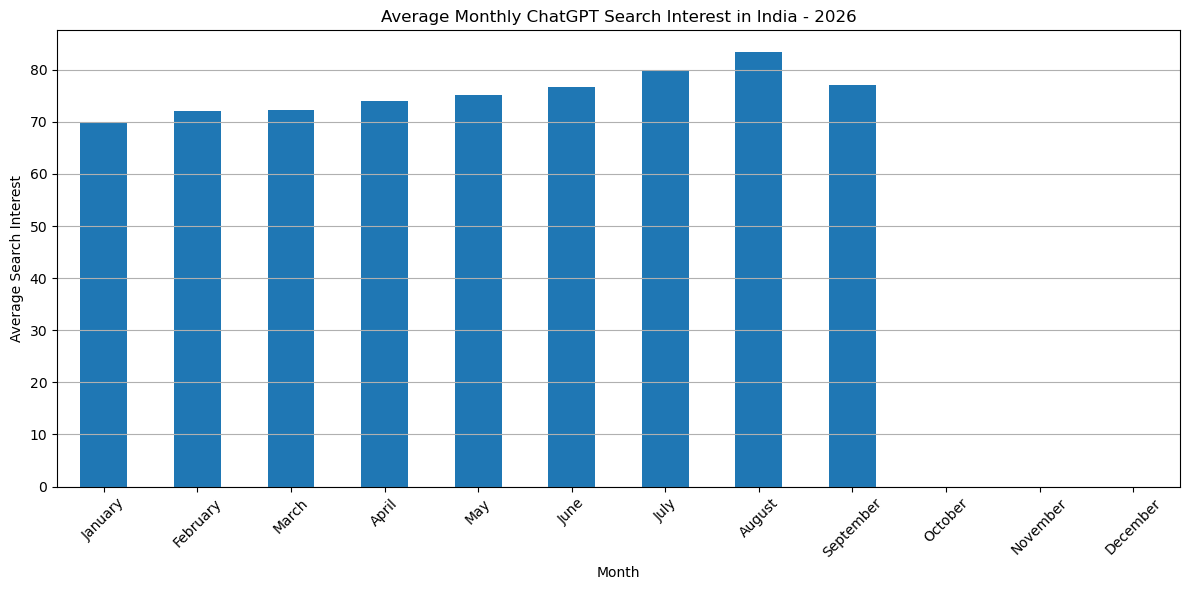

In [180]:
plt.figure(figsize=(12, 6))

monthly_average.plot(kind="bar")

plt.title("Average Monthly ChatGPT Search Interest in India - 2026")
plt.xlabel("Month")
plt.ylabel("Average Search Interest")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## 8. Key Statistical Insights

In this section, we calculate important statistics such as average search interest, peak search interest, lowest search interest, and the periods with the largest changes.

In [182]:
average_interest = df["chatgpt"].mean()

print("Average search interest:", round(average_interest, 2))

Average search interest: 75.68


In [183]:
peak_index = df["chatgpt"].idxmax()

print("Peak date:", df.loc[peak_index, "Time"])
print("Peak search interest:", df.loc[peak_index, "chatgpt"])

Peak date: 2026-09-06 00:00:00
Peak search interest: 100


In [184]:
lowest_index = df["chatgpt"].idxmin()

print("Lowest date:", df.loc[lowest_index, "Time"])
print("Lowest search interest:", df.loc[lowest_index, "chatgpt"])

Lowest date: 2026-09-13 00:00:00
Lowest search interest: 65


In [185]:
top_10 = df.nlargest(10, "chatgpt")

top_10[["Time", "chatgpt"]]

,Time,chatgpt
35,2026-09-06,100
34,2026-08-30,89
32,2026-08-16,87
31,2026-08-09,83
27,2026-07-12,82
28,2026-07-19,81
29,2026-07-26,81
16,2026-04-26,79
30,2026-08-02,79
33,2026-08-23,79


In [186]:
df["Change"] = df["chatgpt"].diff()

In [187]:
largest_increase = df.loc[df["Change"].idxmax()]

print("Largest increase:")
print(largest_increase[["Time", "chatgpt", "Change"]])

Largest increase:
Time       2026-09-06 00:00:00
chatgpt                    100
Change                    11.0
Name: 35, dtype: object


In [188]:
largest_decrease = df.loc[df["Change"].idxmin()]

print("Largest decrease:")
print(largest_decrease[["Time", "chatgpt", "Change"]])

Largest decrease:
Time       2026-09-13 00:00:00
chatgpt                     65
Change                   -35.0
Name: 36, dtype: object


## 9. Distribution of Search Interest

A histogram is used to understand how frequently different levels of search interest occurred during the selected period.

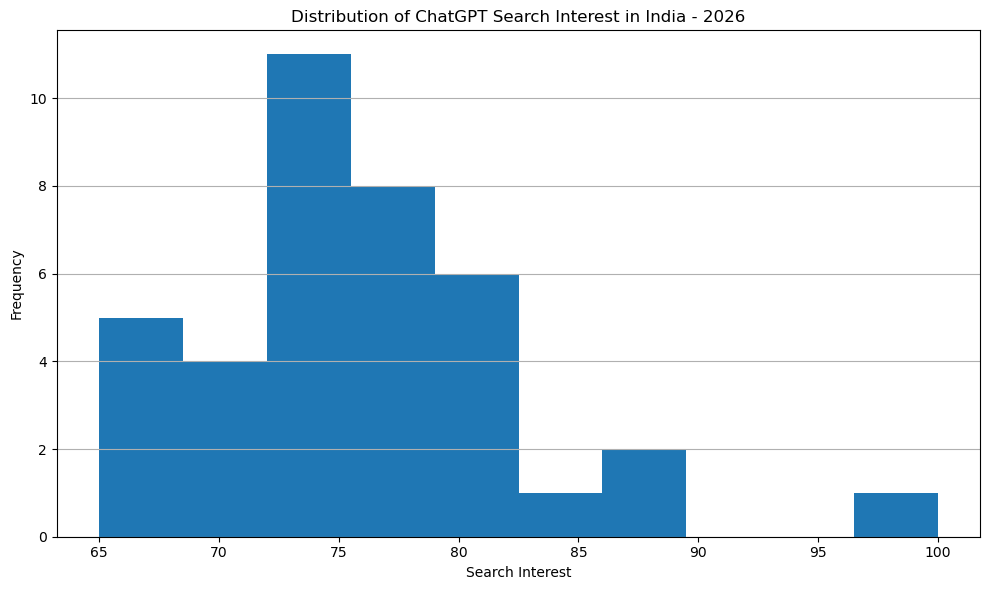

In [189]:
plt.figure(figsize=(10, 6))

plt.hist(df["chatgpt"], bins=10)

plt.title("Distribution of ChatGPT Search Interest in India - 2026")
plt.xlabel("Search Interest")
plt.ylabel("Frequency")

plt.grid(axis="y")
plt.tight_layout()

plt.show()

---

## Project Note

This project was developed as a practical data-analysis project using Python and Google Trends data.

The analysis demonstrates data loading, cleaning, exploratory data analysis, statistical analysis, visualization, and interpretation of real-world search-trend data.